# Lab: Logistic Regression
*In this lab, we will build a basic Logistic Regression model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1: Business Understanding Report (Summary)
> * **Business Context:** A botanical research institute has discovered that the *Iris-virginica* species possesses unique genetic properties that are valuable for developing new floral hybrids. To streamline their research and cultivation efforts, they need a fast and reliable method to distinguish *Iris-virginica* from other iris species like *setosa* and *versicolor*.
> * **Business Problem:** The current process of identifying *Iris-virginica* relies on manual inspection by expert botanist, which is slow, costly, and prone to human error. This bottleneck significantly delays the selection of flowers for research, hindering the institute's progress.
> * **Project Goal:** To build a **predictive classification model** that uses the physical measurements of an iris flower (sepal length, petal width, etc.) to automatically and accurately classify whether it is an *Iris-virginica* or not. The successful model will serve as a fast, cost-effective screening tool for the research team.

---

> ### 📝 2. Analytic Approach Report (Summary)
> * **Problem Type:** *Supervised Binary Classification*, as the goal is to predict a categorical outcome with two classes: "Is Virginica" (1) or "Not Virginica" (0).
> * **Model Selection:** We will use **Logistic Regression (via scikit-learn)** as our baseline model. This is an ideal starting point for classification problems as it is highly interpretable and provides a strong performance baseline.
> * **Evaluation Metrics:**  
>   * **Accuracy:** To get a quick, overall measure of the model's correctness.
>   * **Confusion Matrix:** To provide a detailed breakdown of correct and incorrect predictions for each class (True Positives, False Positives, etc.).
>   * **Precision, Recall, and F1-Score:** To deeply evaluate the model's performance, especially given the slight class imbalance. These metrics give us a nuanced understanding of how well the model identifies the positive class (*Iris-virginica*).
>   * **Data Preparation:** The modeling process will involve splitting the data into training and testing sets (80/20 split) and applying **feature scaling** (`StandardScaler`), as logistic regression benefits from having features on a comparable scale.
> 
> ⚠️ **Caution:** For this foundational lab, Logistic Regression is the only candidate model. In a real-world project, it would be standard practice to compare its performance against other algorithms (like SVMs, Decision Trees, etc.) to select the best possible solution.

---

> ### 📝 3. Data Requirements Report (Summary)
> * **Data Source:** The classic `iris.csv` dataset, which contains data on 150 iris flower samples.
> * **Features (Independent Variables):** `sepal_length`, `sepal_width`, `petal_length`, `petal_width` (all measurements are in centimeters).
> * **Target (Dependent Variable):** The original target is `species` (containing three uniqu classes). This will be transformed into a binary target column, `is_virginica`, where `1` represents *Iris-virginica* and `0` represents any other species.
> * **Granualarity & Privacy:** Each row represents an individual flower specimen. The dataset is a public, anonymized benchmark dataset and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection
We start with importing the necessary libraries and configuring them.

In [223]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")


### 4.1. Extract, Transform, Load (ETL)
Let's extract the data from the source system, which is Scikit-learn's built-in datasets, and perform the ETL process.

In [224]:
# Extract
raw = datasets.load_iris()
print(f"Data has been extracted from the source system as '{type(raw)}'")

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'


In [225]:
# Transform
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['class'] = raw.target
df['class_name'] = raw.target_names[raw.target]

In [226]:
# Load (as CSV)
df.to_csv("./data/iris_interim.csv", index=False)

### 4.2. Initial Data Ingestion and Verification
Let's perform a quick, high-level check to ensure the collected data is readably and appears correct.

In [227]:
df = pd.read_csv("./data/iris_interim.csv")
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class,class_name
86,6.7,3.1,4.7,1.5,1,versicolor
112,6.8,3.0,5.5,2.1,2,virginica
131,7.9,3.8,6.4,2.0,2,virginica
25,5.0,3.0,1.6,0.2,0,setosa
19,5.1,3.8,1.5,0.3,0,setosa


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
 5   class_name         150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB



---

> ### 📝 4. Data Collection Report (Summary)
> * **Data Extraction:** The iris dataset was successfully extracted from Scikit-learn's built-in datasets using the `load_iris()` function.
> * **Data Transformation:** The raw data was transformed into a pandas DataFrame, with appropriate column names assigned. Two new columns were created: `class` (numerical target) and `class_name` (categorical target).
> * **Data Loading:** The transformed DataFrame was saved as a CSV file (`iris_interim.csv`) for further processing.
> * **Initial Verification:** A preliminary inspection of the DataFrame confirmed that the data was loaded correctly, with no missing values and suitable data types for each column.

---

## Stage 5: Data Understanding

### 5.1. Initial Data Shaping
Before diving into analysis, let's perform a first pass of cleaning and shaping.

In [236]:
iris = pd.read_csv("./data/iris_interim.csv")

iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class', 'class_name']
iris['class_name'] = pd.Categorical(iris['class_name'])
iris['class'] = pd.Categorical(iris['class'])
iris['is_virginica'] = pd.Categorical(iris['class_name'] == 'virginica')

iris_numerical = iris.select_dtypes(include=['float64', 'int64'])
iris_categorical = iris.select_dtypes(include=['category'])

* 📌 Renamed columns for better readability, converted `class` and `class_name` columns to categorical data types, and created a binary target column `is_virginica` for the classification task.

### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1 Numerical Features

In [237]:
# Generate the descriptive statistics for the numerical variables
stats_df = iris_numerical.describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,0.141711
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4,0.142564
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9,0.469744
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5,0.635551


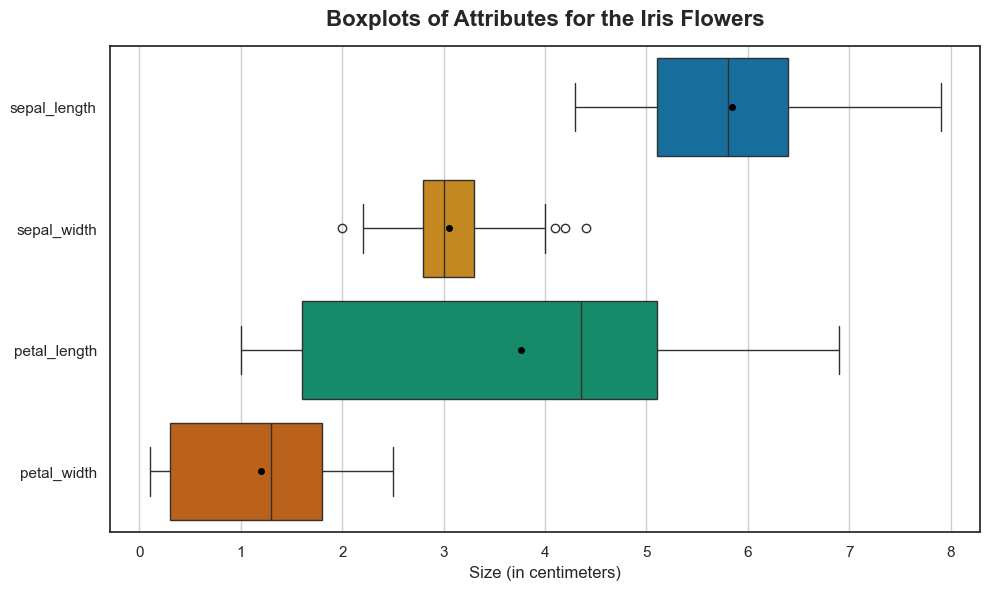

In [235]:
# Visualize the boxplots of numerical independent variables sharing the same units
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_numerical, orient="h", showmeans=True, meanprops={
    "marker": "o",
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "markersize": "4"
})
plt.title("Boxplots of Attributes for the Iris Flowers", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Size (in centimeters)")
plt.grid(axis="x")
plt.show()

* 📌 Temporary

#### 5.2.2. Categorical Features

In [240]:
iris_categorical.describe().T

,count,unique,top,freq
class,150,3,0,50
class_name,150,3,setosa,50
is_virginica,150,2,False,100


<Axes: xlabel='class_name', ylabel='count'>

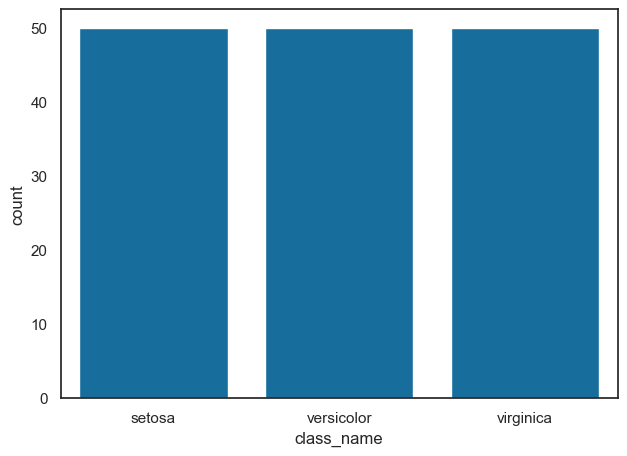

In [244]:
sns.countplot(iris_categorical, x="class_name")

<Axes: xlabel='is_virginica', ylabel='count'>

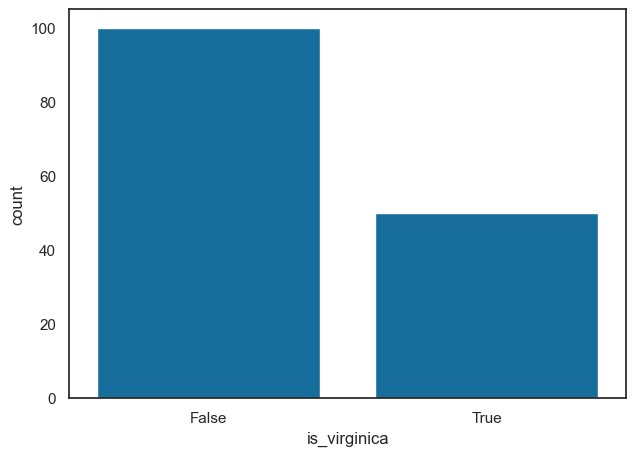

In [246]:
sns.countplot(iris_categorical, x="is_virginica")